In [2]:
import os
import sys
import time

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from torchvision import transforms, ops

BASE_FOLDER = os.path.dirname(os.getcwd())
sys.path.append(BASE_FOLDER)


from src.models import *
from src.utils import *
CHECKPOINTS_FOLDER = os.path.join(BASE_FOLDER,"checkpoints")
device = torch.device("cpu")

print(f"using cude: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("Running on CPU")
    device = torch.device("cpu")

using cude: True
GPU name: NVIDIA GeForce RTX 3060


In [3]:
S = 13
IMG_SIZE = 416 # detection

ALIGN_SIZE = 224

RECOGNITION_SIZE = 112

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CROP_DIR = "detected_and_cropped"
OUTPUT_DIR = "comparison_results"
INPUT_DIR = "img"

os.makedirs(CROP_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(INPUT_DIR, exist_ok=True)

device = torch.device(device=DEVICE)

### Load Detection Model

In [4]:
detector = SimpleDetectionModel()

checkpoint = torch.load(
    os.path.join(CHECKPOINTS_FOLDER, "detection", "face_detector_epoch_9.pth"),
    weights_only=True,
    map_location=device,
)

state_dict = checkpoint["model_state_dict"]
new_state_dict = {}
for k, v in state_dict.items():
    name = k.replace("_orig_mod.", "")
    new_state_dict[name] = v

detector.load_state_dict(new_state_dict)
detector.to(device=device)
detector.eval()

SimpleDetectionModel(
  (model): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (4): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNo

### Load Alignment Model


In [5]:
landmark = LandmarkModel()

checkpoint = torch.load(
    os.path.join(CHECKPOINTS_FOLDER, "alignment", "best_landmark_model_tmp.pth"),
    weights_only=True,
    map_location=device,
)

state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
new_state_dict = {}
for k, v in state_dict.items():
    name = k.replace("_orig_mod.", "")
    new_state_dict[name] = v

landmark.load_state_dict(new_state_dict)
landmark.to(device=device)
landmark.eval()

LandmarkModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

### Load Recognition Model

In [6]:
recognition = MyRecognitionModel(107)

checkpoint = torch.load(
    os.path.join(CHECKPOINTS_FOLDER, "recognition_with_lr_scheduler", "best.pth"),
    weights_only=True,
    map_location=device,
)

recognition.load_state_dict(checkpoint)
recognition.to(device=device)
recognition.eval()

MyRecognitionModel(
  (block1): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
   

### Helper functions

In [7]:
def letterbox_and_map_landmarks(crop, target_size, landmarks_relative):
    h_crop, w_crop = crop.shape[:2]
    tw, th = (target_size, target_size)

    scale = min(tw / w_crop, th / h_crop)
    nw, nh = int(w_crop * scale), int(h_crop * scale)
    img_resized = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((th, tw, 3), dtype=np.uint8)
    dx, dy = (tw - nw) // 2, (th - nh) // 2
    canvas[dy:dy+nh, dx:dx+nw] = img_resized

    new_landmarks = [( (lx * scale + dx) / tw, (ly * scale + dy) / th ) for (lx, ly) in landmarks_relative]
    return canvas, new_landmarks

def rotate_only(img, landmarks):

    left_eye = landmarks[0]
    right_eye = landmarks[1]

    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]

    angle = np.degrees(np.arctan2(dy, dx))

    eye_center = (
        float((left_eye[0] + right_eye[0]) / 2),
        float((left_eye[1] + right_eye[1]) / 2)
    )

    M = cv2.getRotationMatrix2D(eye_center, angle, scale=1.0)

    h, w = img.shape[:2]
    rotated_img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC)

    return rotated_img

# cho camera
def letterbox(img, target_size):

    h, w = img.shape[:2]
    tw, th = (target_size, target_size) if isinstance(target_size, int) else target_size

    scale = min(tw / w, th / h)
    nw, nh = int(w * scale), int(h * scale)

    img_resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((th, tw, 3), dtype=np.uint8)
    dx, dy = (tw - nw) // 2, (th - nh) // 2
    canvas[dy:dy+nh, dx:dx+nw] = img_resized

    return canvas

### Face Detection

In [8]:
def detect_and_crop_celeba_style(img_path, detector_model=None, show=True, collect=False):

    active_detector = detector_model if detector_model else detector
    active_detector.eval()

    frame = cv2.imread(img_path)
    if frame is None:
        print(f"Không thể đọc ảnh: {img_path}")
        return None

    orig_h, orig_w = frame.shape[:2]
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # preprocess
    target_size = 416
    img_res = cv2.resize(frame, (target_size, target_size))
    img_rgb = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # inference
    with torch.no_grad():
        pred = active_detector(img_tensor)

    pred = pred[0].view(-1, 5)
    conf = torch.sigmoid(pred[:, 4])
    mask = conf > 0.4

    if mask.sum() == 0:
        print(f"Không tìm thấy mặt trong {base_name}")
        return None

    # grid
    grid_size = S # 13
    j, i = torch.meshgrid(torch.arange(grid_size, device=device),
                          torch.arange(grid_size, device=device), indexing="xy")
    grid = torch.stack([j, i], dim=-1).view(-1, 2)

    boxes_raw = pred[mask][:, :4]
    scores = conf[mask]
    grid_idx = grid[mask]

    x_center = (torch.sigmoid(boxes_raw[:, 0]) + grid_idx[:, 0]) / grid_size
    y_center = (torch.sigmoid(boxes_raw[:, 1]) + grid_idx[:, 1]) / grid_size
    bw_norm, bh_norm = boxes_raw[:, 2], boxes_raw[:, 3]

    x1s = (x_center - bw_norm / 2) * orig_w
    y1s = (y_center - bh_norm / 2) * orig_h
    x2s = (x_center + bw_norm / 2) * orig_w
    y2s = (y_center + bh_norm / 2) * orig_h

    boxes = torch.stack([x1s, y1s, x2s, y2s], dim=1)
    keep = ops.nms(boxes, scores, 0.3)

    # bbox image
    debug_img = frame.copy()

    for count, idx in enumerate(keep, 1):
        x1, y1, x2, y2 = boxes[idx].tolist()
        bw, bh = x2 - x1, y2 - y1

        cv2.rectangle(debug_img,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      (0, 255, 0), 3)


        # crop
        ix1, iy1 = int(max(0, x1 - bw*0.15)), int(max(0, y1 - bh*0.2))
        ix2, iy2 = int(min(orig_w, x2 + bw*0.15)), int(min(orig_h, y2 + bh*0.06))

        face_crop = frame[iy1:iy2, ix1:ix2]

        if face_crop.size > 0:
            face_final, _ = letterbox_and_map_landmarks(face_crop, 224, [])

            save_name = f"refined_crop_{base_name}.png"
            save_path = os.path.join(CROP_DIR, save_name)
            cv2.imwrite(save_path, face_final)

    if collect:
        return debug_img, base_name

    if show:
        plt.figure(figsize=(2, 2))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title(base_name, fontsize=10)
        plt.axis('off')
        plt.tight_layout(pad=0.3)
        plt.show()

    return None

Không tìm thấy mặt trong 5


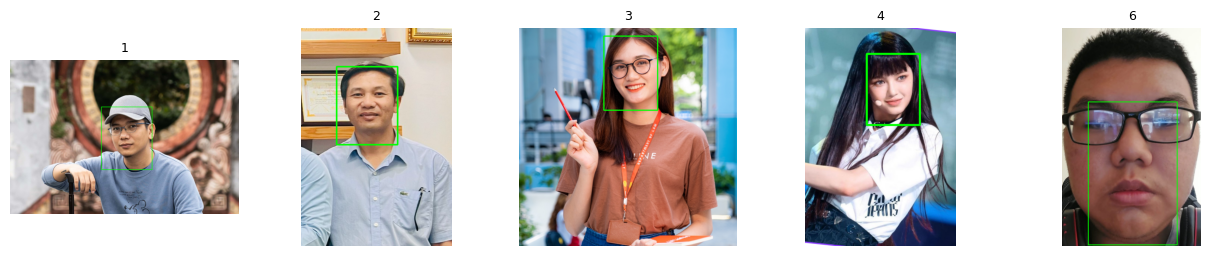

In [9]:
def run_horizontal():
    files = [f for f in os.listdir(INPUT_DIR)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    results = []
    for f in files:
        img_path = os.path.join(INPUT_DIR, f)
        out = detect_and_crop_celeba_style(img_path, show=False, collect=True)

        if out:
            results.append(out)

    n = len(results)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    for i, (img, name) in enumerate(results):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(name, fontsize=9)
        plt.axis('off')

    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    plt.show()

run_horizontal()

### Face Alignment

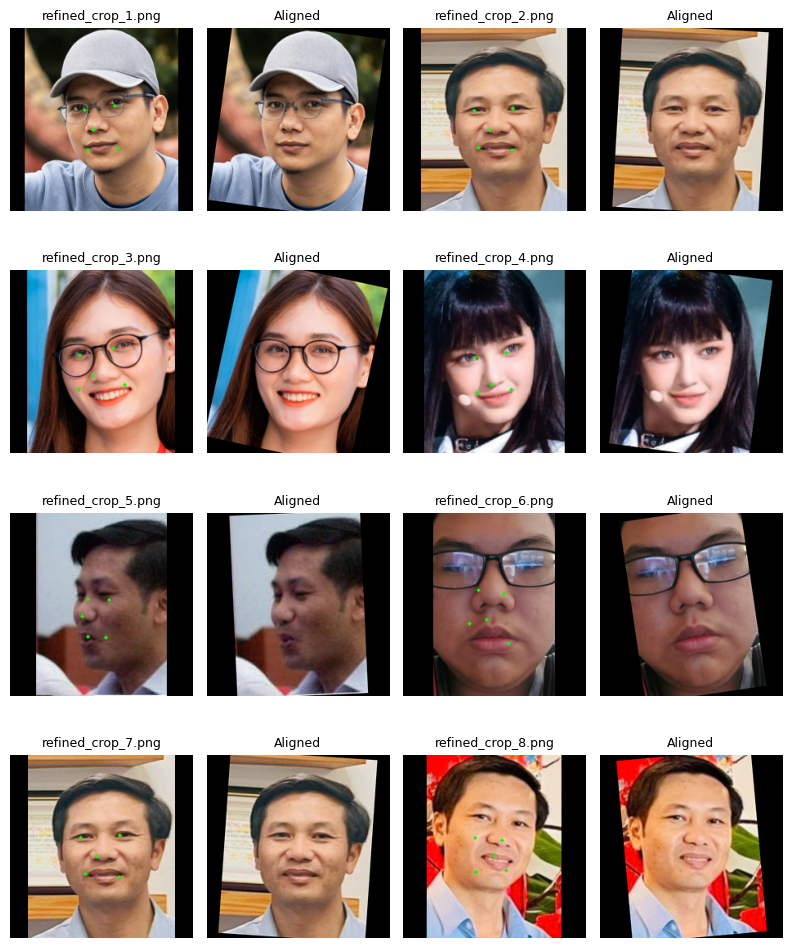

In [10]:
def run_comparison():
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    files = [f for f in os.listdir(CROP_DIR)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not files:
        print("CROP_DIR rỗng")
        return

    pairs = []

    for name in files:
        img_path = os.path.join(CROP_DIR, name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # preprocess
        input_img, _ = letterbox_and_map_landmarks(img, ALIGN_SIZE, [])
        img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        input_tensor = preprocess(img_rgb).unsqueeze(0).to(device)

        # inference
        with torch.no_grad():
            output = landmark(input_tensor)
            preds = output[0].cpu().numpy()
            landmarks = preds * ALIGN_SIZE

        # align
        rotated_img = rotate_only(input_img, landmarks)

        debug_img = input_img.copy()
        for (x, y) in landmarks:
            cv2.circle(debug_img, (int(x), int(y)), 2, (0, 255, 0), -1)

        debug_rgb = cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB)
        rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

        pairs.append((debug_rgb, rotated_rgb, name))

        comparison = np.hstack((debug_img, rotated_img))
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"comp_{name}"), comparison)


    if not pairs:
        print("Không có ảnh hợp lệ")
        return

    pairs_per_row = 2
    cols = pairs_per_row * 2
    rows = (len(pairs) + pairs_per_row - 1) // pairs_per_row

    plt.figure(figsize=(cols * 2, rows * 2.5))

    for i, (img1, img2, name) in enumerate(pairs):
        row = i // pairs_per_row
        col = (i % pairs_per_row) * 2

        # landmark
        plt.subplot(rows, cols, row * cols + col + 1)
        plt.imshow(img1)
        plt.title(name, fontsize=9)
        plt.axis('off')

        # aligned
        plt.subplot(rows, cols, row * cols + col + 2)
        plt.imshow(img2)
        plt.title("Aligned", fontsize=9)
        plt.axis('off')

    plt.tight_layout(pad=1)
    plt.show()

run_comparison()

### Face Recognition

In [11]:
with open(os.path.join(CHECKPOINTS_FOLDER,'recognition_with_lr_scheduler','labels.txt'),'r',encoding='utf-8') as f:
    class_names = sorted([line.strip() for line in f if line.strip()])
    
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

In [12]:
recognition_transform = transforms.Compose(
    [
        SquarePad(),
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
    ]
)


def run_recognition(model, image: Image, transform, device: torch.device):
    model.to(device)
    model.eval() 

    with torch.no_grad():
        image = transform(image)
        image = image.unsqueeze(0)

        image = image.to(device)
        outputs = model(image)

        preds = torch.argmax(outputs, dim=1)

    return preds.item()

In [ ]:
test = os.listdir(os.path.join(BASE_FOLDER,"data","test"))

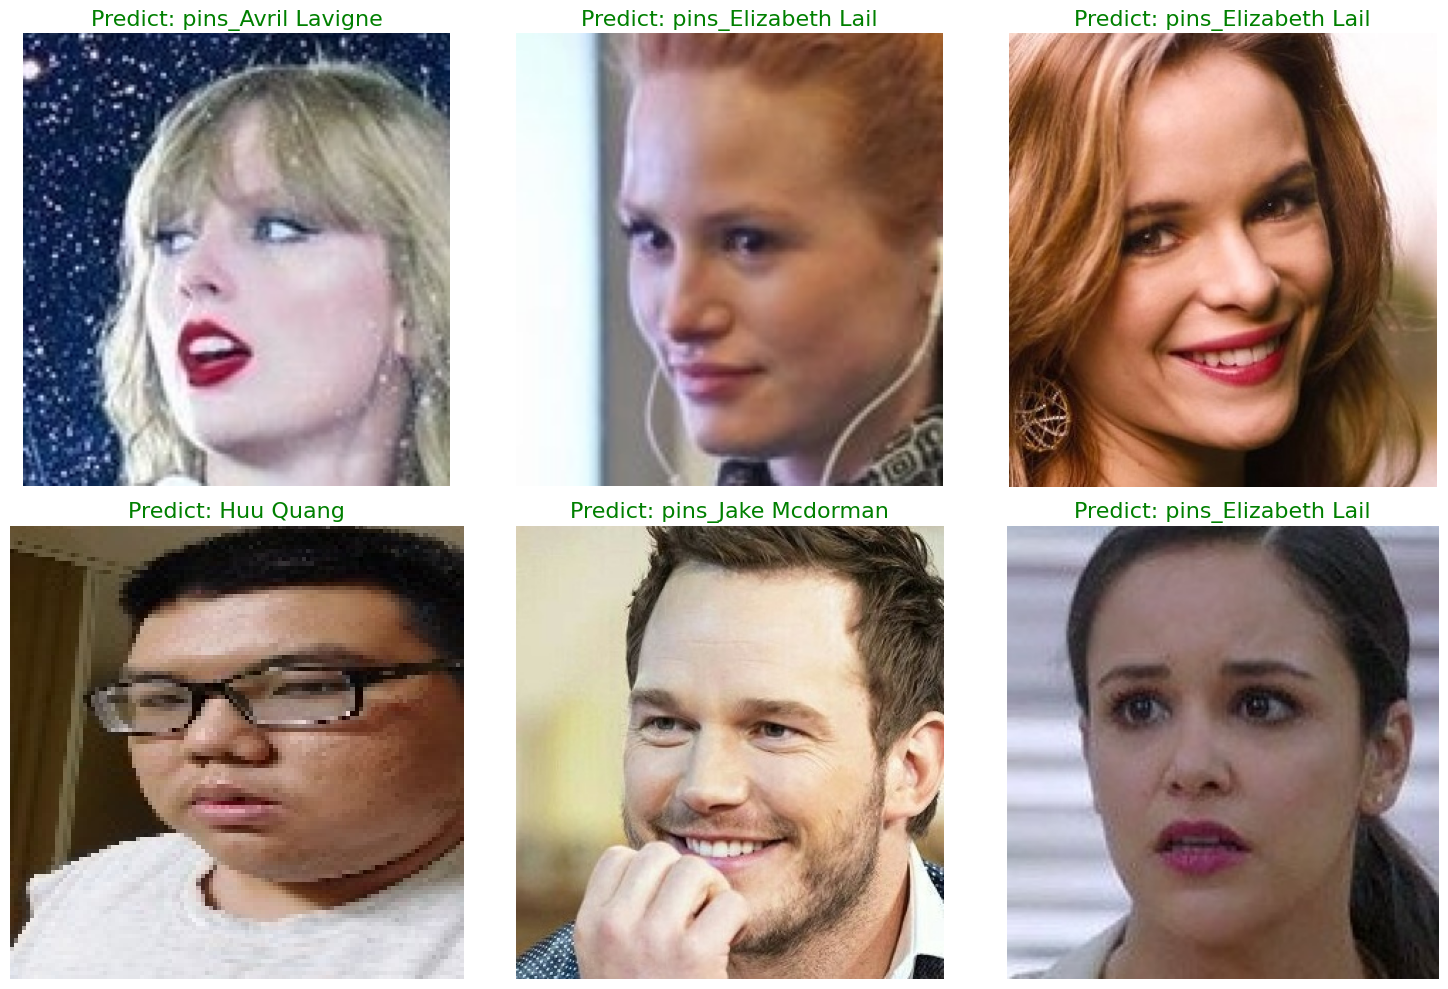

In [29]:
import random

sample = random.sample(test, min(6, len(test)))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
for i, filename in enumerate(sample):
    ax = axes.flat[i]

    image_path = os.path.join(BASE_FOLDER, "data", "test", filename)
    image = Image.open(image_path).convert("RGB")

    pred = run_recognition(
        model=recognition,
        image=image,
        transform=recognition_transform,
        device=device,
    )

    pred_label = class_names[pred]

    ax.imshow(image)
    ax.set_title(f"Predict: {pred_label}", color="green", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Pipeline Camera

In [15]:
    # cap = cv2.VideoCapture(0)
    # detector.to(device)
    # landmark.to(device)
    # detector.eval()
    # landmark.eval()
    # landmark_preprocess = transforms.Compose([
    #     transforms.ToPILImage(),
    #     transforms.ToTensor(),
    # ])

    # print("starting")

    # while True:
    #     ret, frame = cap.read()
    #     if not ret:
    #         break

    #     frame = cv2.flip(frame, 1)

    #     orig_h, orig_w = frame.shape[:2]
    #     display_frame = frame.copy()

    #     # face detection
    #     img_res = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    #     img_rgb = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
    #     img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    #     img_tensor = img_tensor.unsqueeze(0).to(device)

    #     with torch.no_grad():
    #         det_pred = detector(img_tensor)

    #     det_pred = det_pred[0].view(-1, 5)
    #     conf = torch.sigmoid(det_pred[:, 4])
    #     mask = conf > 0.6

    #     if mask.sum() > 0:
    #         j, i = torch.meshgrid(torch.arange(S, device=device), torch.arange(S, device=device), indexing="xy")
    #         grid = torch.stack([j, i], dim=-1).view(-1, 2)

    #         boxes_raw = det_pred[mask][:, :4]
    #         scores = conf[mask]
    #         grid_idx = grid[mask]

    #         x1s = ((boxes_raw[:, 0] + grid_idx[:, 0]) / S - boxes_raw[:, 2] / 2) * orig_w
    #         y1s = ((boxes_raw[:, 1] + grid_idx[:, 1]) / S - boxes_raw[:, 3] / 2) * orig_h
    #         x2s = ((boxes_raw[:, 0] + grid_idx[:, 0]) / S + boxes_raw[:, 2] / 2) * orig_w
    #         y2s = ((boxes_raw[:, 1] + grid_idx[:, 1]) / S + boxes_raw[:, 3] / 2) * orig_h

    #         boxes = torch.stack([x1s, y1s, x2s, y2s], dim=1)
    #         keep = ops.nms(boxes, scores, 0.3)

    #         for idx in keep:
    #             x1, y1, x2, y2 = boxes[idx].tolist()

    #     # crop & landmark
    #             bw, bh = x2 - x1, y2 - y1
    #             cx1, cy1 = int(max(0, x1 - bw * 0.1)), int(max(0, y1 - bh * 0.2))
    #             cx2, cy2 = int(min(orig_w, x2 + bw * 0.1)), int(min(orig_h, y2 + bh * 0.1))

    #             face_crop = frame[cy1:cy2, cx1:cx2]
    #             if face_crop.size == 0: continue

    #             face_padded = letterbox(face_crop, ALIGN_SIZE)
    #             face_rgb = cv2.cvtColor(face_padded, cv2.COLOR_BGR2RGB)
    #             face_tensor = landmark_preprocess(face_rgb).unsqueeze(0).to(device)

    #             with torch.no_grad():
    #                 lms_pred = landmark(face_tensor)
    #                 landmarks = lms_pred[0].cpu().numpy() * ALIGN_SIZE


    #             def to_orig(p):
    #                 px = cx1 + p[0] * (cx2 - cx1) / ALIGN_SIZE
    #                 py = cy1 + p[1] * (cy2 - cy1) / ALIGN_SIZE
    #                 return (int(px), int(py))


    #             real_eye_l = to_orig(landmarks[0])
    #             real_eye_r = to_orig(landmarks[1])
    #             avg_y = (real_eye_l[1] + real_eye_r[1]) // 2

    #             cv2.rectangle(display_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    #             cv2.circle(display_frame, real_eye_l, 4, (0, 255, 255), -1)
    #             cv2.circle(display_frame, real_eye_r, 4, (0, 255, 255), -1)
    #             cv2.line(display_frame, (0, avg_y), (orig_w, avg_y), (255, 0, 0), 1)

    #             rotated_face = rotate_only(face_padded, landmarks)

    #             eye_y_rot = int((landmarks[0][1] + landmarks[1][1]) / 2)
    #             cv2.line(rotated_face, (0, eye_y_rot), (ALIGN_SIZE, eye_y_rot), (0, 0, 255), 1)

    #             display_frame[10:10 + ALIGN_SIZE, 10:10 + ALIGN_SIZE] = rotated_face
    #             cv2.rectangle(display_frame, (10, 10), (10 + ALIGN_SIZE, 10 + ALIGN_SIZE), (255, 255, 255), 2)

    #     cv2.imshow("", display_frame)

    #     if cv2.waitKey(1) & 0xFF == ord('q'):
    #         break

    # cap.release()
    # cv2.destroyAllWindows()

In [16]:
import torch.nn as nn
import torch

landmark_preprocess = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.ToTensor(),
    ]
)


def predict(
    image: Image,
    # labels: dict,
    detector: nn.Module,
    landmark: nn.Module,
    # recognition: nn.Module,
    device: torch.device,
):
    detector.to(device).eval()
    landmark.to(device).eval()
    # recognition.to(device).eval()

    image_rgb = np.array(image.convert("RGB"))
    frame = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    orig_h, orig_w = frame.shape[:2]

    # 2. Face Detection
    img_res = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img_tensor = (
        torch.from_numpy(img_res)
        .permute(2, 0, 1)
        .float()
        .div(255.0)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        det_pred = detector(img_tensor)

    det_pred = det_pred[0].view(-1, 5)
    conf = torch.sigmoid(det_pred[:, 4])
    mask = conf > 0.6

    if mask.sum() == 0:
        plt.imshow(image_rgb)
        plt.title("No face detected")
        plt.axis("off")
        plt.show()
        return

    j, i = torch.meshgrid(
        torch.arange(S, device=device), torch.arange(S, device=device), indexing="xy"
    )
    grid = torch.stack([j, i], dim=-1).view(-1, 2)
    boxes_raw = det_pred[mask][:, :4]
    grid_idx = grid[mask]

    x1s = ((boxes_raw[:, 0] + grid_idx[:, 0]) / S - boxes_raw[:, 2] / 2) * orig_w
    y1s = ((boxes_raw[:, 1] + grid_idx[:, 1]) / S - boxes_raw[:, 3] / 2) * orig_h
    x2s = ((boxes_raw[:, 0] + grid_idx[:, 0]) / S + boxes_raw[:, 2] / 2) * orig_w
    y2s = ((boxes_raw[:, 1] + grid_idx[:, 1]) / S + boxes_raw[:, 3] / 2) * orig_h

    boxes = torch.stack([x1s, y1s, x2s, y2s], dim=1)
    keep = ops.nms(boxes, conf[mask], 0.3)

    for idx in keep:
        x1, y1, x2, y2 = boxes[idx].tolist()

        bw, bh = x2 - x1, y2 - y1
        cx1, cy1 = int(max(0, x1 - bw * 0.1)), int(max(0, y1 - bh * 0.2))
        cx2, cy2 = int(min(orig_w, x2 + bw * 0.1)), int(min(orig_h, y2 + bh * 0.1))
        face_crop = frame[cy1:cy2, cx1:cx2]
        if face_crop.size == 0:
            continue

        # Landmark Detection
        face_padded = letterbox(face_crop, ALIGN_SIZE)
        face_tensor = (
            landmark_preprocess(cv2.cvtColor(face_padded, cv2.COLOR_BGR2RGB))
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():
            lms_pred = landmark(face_tensor)
            landmarks_local = lms_pred[0].cpu().numpy() * ALIGN_SIZE

            rotated_face = rotate_only(face_padded, landmarks_local)
            rotated_rgb = cv2.cvtColor(rotated_face, cv2.COLOR_BGR2RGB)

            # Recognition
            rec_tensor = landmark_preprocess(rotated_rgb).unsqueeze(0).to(device)
            # out = recognition(rec_tensor)
            # prob = torch.softmax(out, dim=1)
            # score, class_id = torch.max(prob, dim=1)
            # pred_label = labels.get(class_id.item(), "Unknown")

        def to_global(p):
            px = cx1 + p[0] * (cx2 - cx1) / ALIGN_SIZE
            py = cy1 + p[1] * (cy2 - cy1) / ALIGN_SIZE
            return [px, py]

        landmarks_global = np.array([to_global(p) for p in landmarks_local])

        fig, ax = plt.subplots(1, 2, figsize=(16, 8))

        ax[0].imshow(image_rgb)
        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", linewidth=2
        )
        ax[0].add_patch(rect)
        ax[0].scatter(
            landmarks_global[:, 0],
            landmarks_global[:, 1],
            c="red",
            s=25,
            edgecolors="white",
            label="Raw LMs",
        )
        for i, (lx, ly) in enumerate(landmarks_global):
            ax[0].text(
                lx + 2, ly + 2, str(i), color="yellow", fontsize=8
            ) 
        ax[0].set_title("Detection & Raw Landmarks")
        ax[0].axis("off")

        ax[1].imshow(rotated_rgb)
        ax[1].scatter(
            landmarks_local[:, 0],
            landmarks_local[:, 1],
            c="cyan",
            s=35,
            marker="x",
            label="Refined LMs",
        )
        eye_y = (landmarks_local[0][1] + landmarks_local[1][1]) / 2
        ax[1].axhline(y=eye_y, color="red", linestyle="--", linewidth=1, alpha=0.5)

        # ax[1].set_title(f"Aligned - Predict: {pred_label} ({score.item():.2%})")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()

In [17]:
image = Image.open(os.path.join(BASE_FOLDER, "notebooks", "img", "8.jpg")).convert(
    "RGB"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

predict(image=image, detector=detector, landmark=landmark, device=device)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/d/projects/FaID-System/notebooks/img/8.jpg'

In [ ]:

import cv2
import torch
import os
from torchvision import ops, transforms

def collect_diverse_face_crops(video_path, save_folder, detector, device):
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    # Đưa model về chế độ eval để detect ổn định
    detector.to(device).eval()
    
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    segment_size = total_frames / 100
    
    count = 0
    print(f"🚀 Tổng số frame: {total_frames}. Đang trích xuất 100 ảnh crop đa dạng...")

    for i in range(100):
        start_frame = int(i * segment_size)
        end_frame = int((i + 1) * segment_size)
        
        best_crop = None
        max_conf_in_segment = 0
        
        for frame_idx in range(start_frame, end_frame, 2):
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: break

            orig_h, orig_w = frame.shape[:2]
            
            img_res = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            img_rgb = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
            img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                det_pred = detector(img_tensor)
            
            det_pred = det_pred[0].view(-1, 5)
            conf = torch.sigmoid(det_pred[:, 4])
            
            if conf.max() > 0.6 and conf.max() > max_conf_in_segment:
                max_conf_in_segment = conf.max().item()
                mask = conf == conf.max()
                
                # Tính toán tọa độ Box
                j, i_grid = torch.meshgrid(torch.arange(S, device=device), torch.arange(S, device=device), indexing="xy")
                grid = torch.stack([j, i_grid], dim=-1).view(-1, 2)
                
                boxes_raw = det_pred[mask][0, :4]
                grid_idx = grid[mask][0]
                
                x1 = ((boxes_raw[0] + grid_idx[0]) / S - boxes_raw[2] / 2) * orig_w
                y1 = ((boxes_raw[1] + grid_idx[1]) / S - boxes_raw[3] / 2) * orig_h
                x2 = ((boxes_raw[0] + grid_idx[0]) / S + boxes_raw[2] / 2) * orig_w
                y2 = ((boxes_raw[1] + grid_idx[1]) / S + boxes_raw[3] / 2) * orig_h

                # Crop với một chút margin (lề) để lấy đủ khuôn mặt
                bw, bh = x2 - x1, y2 - y1
                cx1, cy1 = int(max(0, x1 - bw * 0.05)), int(max(0, y1 - bh * 0.05))
                cx2, cy2 = int(min(orig_w, x2 + bw * 0.05)), int(min(orig_h, y2 + bh * 0.05))

                best_crop = frame[cy1:cy2, cx1:cx2]

        # Lưu ảnh crop tốt nhất của đoạn 1% này
        if best_crop is not None and best_crop.size > 0:
            # Resize về kích thước chuẩn mà model train của bạn yêu cầu (ví dụ 112x112)
            # Bạn có thể dùng hàm letterbox của bạn ở đây nếu muốn giữ tỉ lệ
            final_face = cv2.resize(best_crop, (112, 112)) 
            
            save_path = os.path.join(save_folder, f"face_crop_{count:03d}.jpg")
            cv2.imwrite(save_path, final_face)
            count += 1

    cap.release()
    print(f"✅ Hoàn thành! Thu được {count} ảnh crop đa dạng (không align).")    
    
collect_diverse_face_crops('/mnt/d/projects/FaID-System/data/5b0f2eef-87de-4d20-9a66-5186fc901665.mp4', '/mnt/d/projects/FaID-System/data/finetune/Huu Quang', detector,  device)

🚀 Tổng số frame: 0. Đang trích xuất 100 ảnh crop đa dạng...
✅ Hoàn thành! Thu được 0 ảnh crop đa dạng (không align).


: 

: 